# Start of Notebook

In [1]:
import os
import warnings
import random
import pickle
from datetime import datetime
from collections import defaultdict
from functools import partial

# Environment configuration
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=8'

import numpyro
from numpyro import distributions as dist
from numpyro.infer import MCMC, NUTS, log_likelihood, hmc
from numpyro.infer.util import initialize_model
from numpyro.util import fori_collect

import jax
from jax import config
config.update("jax_enable_x64", True)
config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp
from jax import jit, pmap, devices, device_get, lax, local_device_count, random, vmap, block_until_ready
from jax.random import PRNGKey, split
from jax.scipy.optimize import minimize
from jax.scipy.signal import fftconvolve
from jax.scipy.signal import convolve as jax_convolve

# Check devices
print('Available devices:', devices())
print('CPU devices:', devices('cpu'))

# Suppress warnings
warnings.filterwarnings('ignore', message="It appears that you're using a Mac with one of Apple's ARM-based processors")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, to_hex
import corner

import astropy.units as u
import astropy.constants as c
from astropy.constants import G, m_p
from astropy.table import Table

import shone

import fleck
from fleck.jax import ActiveStar

from scipy.optimize import fmin_powell, curve_fit
from scipy.stats import gaussian_kde

from chromatic import *
from svo_filters import svo
from bt_settl import get_interp_stellar_spectrum
from bt_settl_3d import get_interp_stellar_spectrum_3d

import arviz
import arviz as az

from tqdm.auto import tqdm
from glob import glob

# Create custom binned bin edges
wl_min, wl_max = 0.7, 1.7
n_points = 10000

# Use log-spacing for better sampling in the infrared
binned_bin_edges = np.geomspace(wl_min, wl_max, n_points + 1)
# Or use linear spacing if you prefer:
# binned_bin_edges = np.linspace(wl_min, wl_max, n_points + 1)

binned_wavelengths = (binned_bin_edges[:-1] + binned_bin_edges[1:]) / 2.0

print(f"Creating custom binned grid with {n_points} points from {wl_min} to {wl_max} µm")
print(f"Binned bin edges shape: {len(binned_bin_edges)}")
print(f"Binned wavelengths shape: {len(binned_wavelengths)}")

# Step 2: Create the interpolation grid using these custom bin edges
print("\nCreating BT-Settl 3D interpolation grid with custom binning...")
panchromatic_btsettl_grid = get_interp_stellar_spectrum_3d(binned_bin_edges)
panchromatic_wavelengths = binned_wavelengths
panchromatic_bin_edges = binned_bin_edges

print(f"\nWavelength range: {panchromatic_wavelengths[0]:.3f} - {panchromatic_wavelengths[-1]:.3f} µm")
print(f"Number of wavelength points: {len(panchromatic_wavelengths)}")
print("\nGrid creation complete!")

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]


2026-03-23 11:18:11,201 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/chromatic/imports.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import copy, pkg_resources, os, glob, pickle


Creating custom binned grid with 10000 points from 0.7 to 1.7 µm
Binned bin edges shape: 10001
Binned wavelengths shape: 10000

Creating BT-Settl 3D interpolation grid with custom binning...
Total missing grid points: 64

Wavelength range: 0.700 - 1.700 µm
Number of wavelength points: 10000

Grid creation complete!


In [3]:
visits = {
    'F21': {
        'Grism': 'G141',
        # 'Forward': G_141_for_dict,
        # 'Backward': G_141_back_dict,
        'BJD_times': np.array(pd.read_csv('../../data/F21_bjdtimes.csv')['BJD'][:]) * u.day,
        'time_lower': 2459455.708 * u.day,
        'time_upper': 2459455.738 * u.day,
        'T0 (BJD_TDB)': 2459455.9895 * u.day,
        'exp (s)': 4.9784 * u.s,
        'native resolution': 46.3 * u.angstrom
    },
    'S22': {
        'Grism': 'G102',
        # 'Forward': G_102_for_dict,
        # 'Backward': G_102_back_dict,
        'BJD_times': np.array(pd.read_csv('../../data/S22_bjdtimes.csv')['BJD'][:]) * u.day,
        'time_lower': 2459684.215 * u.day,
        'time_upper': 2459684.243 * u.day,
        'T0 (BJD_TDB)': 2459684.4959 * u.day, # This is 27 planetary orbits after the first transit, + 0.0054 days (the transit arrived 7 minutes late)
        'exp (s)': 9.67632 * u.s,
        'native resolution': 24.6 * u.angstrom
    }
}

systeminfo = {
    'duration (hr)': 3.5 * u.hr,
    'T_orb (d)': 8.463 * u.day,
    'T_rot (d)': 4.86 * u.day,
    'inclination': 89.5,
    'eccentricity': 0.0,
    'longitude_of_periastron': 88.4
}

def read_sensitivity_curve(grism='G141'):
    path = f'../../data/WFC3.IR.{grism}.1st.sens.2.fits'

    response = fits.open(path)

    w = response[1].data['wavelength']/1e4 * u.micron
    s = response[1].data['sensitivity'] * u.cm * u.cm / u.erg
    e = response[1].data['error'] * u.cm * u.cm / u.erg
    
    return w, s, e

@jit
def get_planck_spectrum_jax(T, **kwargs):
    """
    Calculate the surface flux from a thermally emitted surface,
    according to Planck function.

    Parameters
    ----------
    wavelength : Quantity
        The wavelengths at which to calculate,
        with units of wavelength.
    temperature : Quantity
        The temperature of the thermal emitter,
        with units of K.

    Returns
    -------
    surface_flux : Quantity
        The surface flux, evaluated at the wavelengths.
    """

    # define variables as shortcut to the constants we need
    h = 6.62607e-27 # erg s
    k = 1.380649e-16 # erg/K
    c = 2.9979e18 # angstrom/s
    wavelength = panchromatic_wavelengths*1e4

    z = h * c / (wavelength * k * T) # units check out

    # calculate the intensity from the Planck function
    intensity = (2 * h * c**2 / wavelength**5 / (jnp.exp(z) - 1)) # Units are erg/s/A^3

    # calculate the flux assuming isotropic emission
    flux = jnp.pi * intensity * 1e16 # erg / (s * cm^2 * angstrom)

    # return the intensity
    wave_jax = jnp.array(panchromatic_wavelengths)
    flux_jax = jnp.array(flux)

    return wave_jax, flux_jax

@jit
def convolve_spectrum_jax(model_wavelength, model_flux, sigma, kernel_size=5, **kwargs):
    """
    Properly convolve a spectrum with a Gaussian kernel in JAX.
    
    Args:
        model_wavelength: Array of wavelengths (must be evenly spaced!)
        model_flux: Corresponding flux values
        sigma: Standard deviation of Gaussian kernel in wavelength units
        kernel_size: Number of elements in the kernel (odd number recommended)
        
    Returns:
        Convolved flux array
    """
    # Ensure inputs are JAX arrays
    model_wavelength = jnp.asarray(model_wavelength)
    model_flux = jnp.asarray(model_flux)
    
    # Create proper Gaussian kernel
    x = jnp.linspace(-(kernel_size//2), kernel_size//2, kernel_size)
    kernel = jnp.exp(-0.5 * (x/sigma)**2)
    kernel = kernel / jnp.sum(kernel)  # normalize
    
    # Perform convolution
    convolved = jax_convolve(model_flux, kernel, mode='same', method='fft')
    
    return convolved

@jit
def get_BTSettl_spectrum_jax(T, 
                             metallicity, 
                             grid=panchromatic_btsettl_grid, **kwargs):
    """
    Get BT-Settl spectrum for given temperature, logg, and metallicity.
    
    Parameters:
    T : effective temperature (K)
    logg : surface gravity (log10(cm/s^2))
    metallicity : metallicity ([M/H])
    grid : 3D interpolation function from get_interp_stellar_spectrum_3d
    
    Returns:
    wave_jax : wavelength array (micrometers)
    flux_jax : flux array (erg/cm^2/s/Å)
    """
    
    # Pass all three parameters to the 3D grid interpolation
    gridspec = grid(
        jnp.array(T, dtype=jnp.float64),
        # jnp.array(logg, dtype=jnp.float32),
        jnp.array(metallicity, dtype=jnp.float64)
    )
    
    # sigma_sb = 5.67e-5  # erg/cm^2/s/K^4
    # nf = (sigma_sb * (T)**4) / (jnp.trapezoid(gridspec, x=jnp.array(panchromatic_wavelengths)*1e4))
    re_normed_flux = gridspec #* nf
    
    wave_jax = jnp.array(panchromatic_wavelengths)
    flux_jax = jnp.array(re_normed_flux)
    
    return wave_jax, flux_jax

## Load Data

  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/110 [00:00<?, ?it/s]

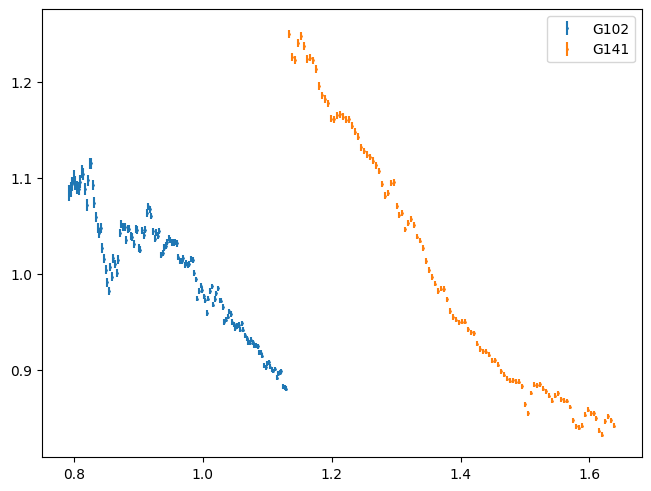

<Figure size 640x480 with 0 Axes>

In [4]:
###############################
# S22
###############################

visit = 'S22'
'Things that automatically get re-defined for either visit'
predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow
'remove the transit'
out_of_transit = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=predicted_T0*u.day, duration=0.15*u.day) )
# out_of_transit.imshow()
'define the appropriate arrays'
_meanOOTspec = out_of_transit.get_average_spectrum_as_rainbow()
meanOOTspec = _meanOOTspec.flux
meanOOTspec_relative_err = _meanOOTspec.uncertainty.value/meanOOTspec.value
oot_spec_err = meanOOTspec_relative_err.flatten()
_SED_wavelengths = (_meanOOTspec.wavelength.value).flatten()
e_per_s = meanOOTspec / exptime
e_per_s_per_angstrom = e_per_s / binwidth
_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=_SED_wavelengths)['y'] * u.cm**2 / u.erg
_calibrated_mean_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
calibrated_mean_spec = _calibrated_mean_spec.value/np.nanmean(_calibrated_mean_spec.value)
oot_spec_err = oot_spec_err * calibrated_mean_spec
# Convert to JAX arrays
calibrated_mean_spec_G102 = jnp.array(calibrated_mean_spec)
oot_spec_err_G102 = jnp.array(oot_spec_err)
SED_wavelengths_G102 = jnp.array(_SED_wavelengths)

###############################
# F21
###############################
visit = 'F21'
'Things that automatically get re-defined for either visit'
predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow
'remove the transit'
out_of_transit = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=predicted_T0*u.day, duration=0.15*u.day) )
'define the appropriate arrays'
_meanOOTspec = out_of_transit.get_average_spectrum_as_rainbow()
meanOOTspec = _meanOOTspec.flux
meanOOTspec_relative_err = _meanOOTspec.uncertainty.value/meanOOTspec.value
_oot_spec_err = meanOOTspec_relative_err.flatten()
_SED_wavelengths = (_meanOOTspec.wavelength.value).flatten()
e_per_s = meanOOTspec / exptime
e_per_s_per_angstrom = e_per_s / binwidth
_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=_SED_wavelengths)['y'] * u.cm**2 / u.erg
_calibrated_mean_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
calibrated_mean_spec = _calibrated_mean_spec.value/np.nanmean(_calibrated_mean_spec.value)
oot_spec_err = _oot_spec_err * calibrated_mean_spec
# Convert to JAX arrays
calibrated_mean_spec_G141 = jnp.array(calibrated_mean_spec)
oot_spec_err_G141 = jnp.array(oot_spec_err)
SED_wavelengths_G141 = jnp.array(_SED_wavelengths)

###############################
# PLOT DATA
###############################
plt.figure()
plt.errorbar(SED_wavelengths_G102,calibrated_mean_spec_G102,yerr=oot_spec_err_G102*100,fmt='o',label='G102',ms=1)
plt.errorbar(SED_wavelengths_G141,calibrated_mean_spec_G141,yerr=oot_spec_err_G141*100,fmt='o',label='G141',ms=1)
plt.legend()
plt.show()
plt.clf()

# Define Numpyro Model

In [5]:
def numpyro_model(N_temps=2, return_max_likelihood=False):
    """
    Define the probabilistic model in NUMPYRO with N_temps components.
    
    Args:
        N_temps: Number of temperature components (1, 2, 3, or 4)
        return_max_likelihood: If True, also return the maximum log likelihood value
    """
    def model():
        temp_bounds = [
            (3600, 4300),   # T1 bounds (higher temperature)
            (2500, 3600),   # T2 bounds (cooler component)
            (1000, 10000),  # T3 bounds 
            (1000, 3200)    # T4 bounds
        ]
        
        'Spectral Decomp Params'
        T_samples = []
        for i in range(1, N_temps + 1):
            if i == 2:
                delta_T = numpyro.sample('delta_T', dist.Uniform(-1000, -200))
                T = numpyro.deterministic(f'T{i}', T_samples[0] + delta_T)        
            else:
                T = numpyro.sample(f'T{i}', dist.Uniform(*temp_bounds[i-1]))
            T_samples.append(T)
        ff_samples = [1.0]  # First component always has f=1
        for i in range(2, N_temps + 1):
            ff = 10**numpyro.sample(f'ff{i}', dist.Uniform(-3, 2))
            ff_samples.append(ff)
        'Gridpoint Params'
        metallicity = numpyro.sample('metallicity', dist.Uniform(-1.0, 0.5))
        # logg = 4.5 #numpyro.sample('logg', dist.Uniform(4.0, 5.0))
        sigma_conv = 4.0
        'Data Params'
        offset_G102 = numpyro.sample('offset_G102', dist.Uniform(0.0, 1.0))
        slope_G141 = numpyro.sample('slope_G141', dist.Uniform(-1.5, 0.5))
        slope_G102 = numpyro.sample('slope_G102', dist.Uniform(-1.5, 0.5))
        beta_102 = numpyro.sample('beta_G102', dist.Uniform(2.0, 2.7))
        beta_141 = numpyro.sample('beta_G141', dist.Uniform(2.0, 2.7))

        'Apply data params'
        offset_102 = jnp.asarray(offset_G102, dtype=jnp.float64)
        spec_G102_with_offset = jnp.array(calibrated_mean_spec_G102 + offset_102)
        spec_G102_with_slope = spec_G102_with_offset + slope_G102 * (SED_wavelengths_G102 - SED_wavelengths_G102[0])
        spec_G141_with_slope = jnp.array(calibrated_mean_spec_G141) + slope_G141 * (SED_wavelengths_G141 - SED_wavelengths_G141[0])
        _spec_flux_jax = jnp.concatenate([spec_G102_with_slope, spec_G141_with_slope])
        
        spec_flux_jax = _spec_flux_jax / jnp.mean(_spec_flux_jax)
        spec_err_jax = jnp.concatenate(
            [
                jnp.array((10**beta_102) * oot_spec_err_G102),
                jnp.array((10**beta_141) * oot_spec_err_G141)
            ]
        )
        combined_SED_wavelengths = jnp.concatenate([jnp.array(SED_wavelengths_G102), 
                                                    jnp.array(SED_wavelengths_G141)])
        
        @jit
        def decomp_model(temps, scales, metal_val, sigma):
            # Get spectra for all temperatures with variable metallicity AND logg
            spectra = [get_BTSettl_spectrum_jax(T=Temp, metallicity=metal_val) 
                       for Temp in temps]
            
            # Calculate combined spectrum with scaling factors
            flux_combined = scales[0] * spectra[0][1]  # Start with first component
            for i in range(1, N_temps):
                flux_combined += scales[i] * spectra[i][1]
            
            # Normalize
            _model_flux = flux_combined / jnp.mean(flux_combined)
            
            # Convolve and bin
            convolved = convolve_spectrum_jax(
                panchromatic_wavelengths, 
                _model_flux, 
                sigma=jnp.asarray(sigma, dtype=jnp.float64)
            )
            binned_model_flux = shone.bin_spectrum(
                combined_SED_wavelengths, 
                panchromatic_wavelengths, 
                convolved
            )
            model_flux = binned_model_flux / jnp.mean(binned_model_flux)
            
            return model_flux

        # Calculate model flux with both metallicity AND logg
        model_flux = decomp_model(T_samples, ff_samples, metallicity, sigma_conv)
        
        # Define the likelihood
        log_likelihood = dist.Normal(model_flux, spec_err_jax).log_prob(spec_flux_jax).sum()
        
        # Add a prior on log likelihood to catch NaN values
        log_likelihood = jnp.where(jnp.isnan(log_likelihood), -1e10, log_likelihood)
        
        # Sample the observed data
        numpyro.sample("Obs", dist.Normal(model_flux, spec_err_jax), obs=spec_flux_jax)
        
        # Track log likelihood for maximum likelihood calculation
        if return_max_likelihood:
            numpyro.deterministic('log_likelihood', log_likelihood)
    
    if return_max_likelihood:
        def get_max_likelihood(samples):
            """Extract maximum log likelihood from samples"""
            log_lik_samples = samples.get('log_likelihood', None)
            if log_lik_samples is not None:
                return float(jnp.max(log_lik_samples))
            return None
        
        return model, get_max_likelihood
    else:
        return model

## Define Checkpoint Function

In [6]:
rng_seed = 0

def hstack_recursive(final_states, checkpoint_states):
    for key in final_states.keys():
        if isinstance(final_states[key], dict):
            hstack_recursive(final_states[key], checkpoint_states[key])
        else:
            final_states[key] = jnp.hstack([
                final_states[key], 
                checkpoint_states[key]
            ])

def print_big_message(big_message):
    print('\n\n')
    print('=' * len(big_message))
    print(big_message)
    print('=' * len(big_message))
    print('\n\n')

def post_batch_viz_save(self, **kwargs):
    """
    here we define some tasks to do after each completed checkpoint:
    """
    print(f'Corner for checkpoint {self.checkpoint}')

    samples_cumulative = self.get_samples()
    corner.corner(samples_cumulative)
    plt.suptitle(f'checkpoint {self.checkpoint}')
    plt.savefig(f'../../figs/joint-visit_chkpt_{self.checkpoint}_sed_corner.png', dpi=200)
    plt.show()
    plt.clf()
    
    # EXTRACT MEDIAN PARAMETERS DIRECTLY FROM SAMPLES (like corner plot does)
    chkpt_median_params = {}
    for param_name, param_samples in samples_cumulative.items():
        # param_samples has shape (num_chains, num_samples)
        # Flatten across chains and compute median
        flattened_samples = param_samples.flatten()
        chkpt_median_params[param_name] = float(jnp.median(flattened_samples))
    
    print("Median parameters from samples:")
    for param, value in chkpt_median_params.items():
        print(f"  {param}: {value:.6f}")
    
    # Calculate and print maximum log likelihood
    if 'log_likelihood' in samples_cumulative:
        log_lik_samples = samples_cumulative['log_likelihood'].flatten()
        max_log_lik = float(jnp.max(log_lik_samples))
        print(f"Maximum log likelihood: {max_log_lik:.6f}")
        
        # Also compute Bayesian Information Criterion (BIC) if you want
        n_params = len([p for p in samples_cumulative.keys() if p != 'log_likelihood'])
        n_data = len(SED_wavelengths_G102) + len(SED_wavelengths_G141)  # number of data points
        bic = -2 * max_log_lik + n_params * jnp.log(n_data)
        print(f"BIC: {bic:.6f}")

    with open(f'../../data/samples/samples_cumulative_{self.start_time}_checkpoint_{self.checkpoint:04d}.pkl', 'wb') as file:
        pickle.dump(dict(samples_cumulative), file)

class MCMCWithCheckpoints(MCMC):
    running_states = None
    checkpoint = 0
    start_time = None
    
    def run_checkpoints(self, rng_key, *args, extra_fields=(), n_checkpoints=10, 
                        progress_bar_warmup=True, progress_bar_samples=True, 
                        init_params=None, on_checkpoint=None, **kwargs):
        """
        Run the MCMC samplers and collect samples.

        :param random.PRNGKey rng_key: Random number generator key to be used for the sampling.
            For multi-chains, a batch of `num_chains` keys can be supplied. If `rng_key`
            does not have batch_size, it will be split in to a batch of `num_chains` keys.
        :param args: Arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init` method.
            These are typically the arguments needed by the `model`.
        :param extra_fields: Extra fields (aside from `"z"`, `"diverging"`) from the
            state object (e.g. :data:`numpyro.infer.hmc.HMCState` for HMC) to be collected
            during the MCMC run. Note that subfields can be accessed using dots, e.g.
            `"adapt_state.step_size"` can be used to collect step sizes at each step. Exclude sample sites from
            collection with "~`sampler.sample_field`.`sample_site`". e.g. "~z.a" will prevent site "a" from
            being collected if you're using the NUTS sampler. To collect samples of a site "a" in the
            unconstrained space, we can specify the variable here, e.g. `extra_fields=("z.a",)`.
        :type extra_fields: tuple or list of str
        :param init_params: Initial parameters to begin sampling. The type must be consistent
            with the input type to `potential_fn` provided to the kernel. If the kernel is
            instantiated by a numpyro model, the initial parameters here correspond to latent
            values in unconstrained space.
        :param kwargs: Keyword arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init`
            method. These are typically the keyword arguments needed by the `model`.

        .. note:: jax allows python code to continue even when the compiled code has not finished yet.
            This can cause troubles when trying to profile the code for speed.
            See https://jax.readthedocs.io/en/latest/async_dispatch.html and
            https://jax.readthedocs.io/en/latest/profiling.html for pointers on profiling jax programs.
        """
        self.start_time = datetime.now().strftime("%Y-%m-%d_%H-%M")
        num_warmup_total = int(self.num_warmup)
        num_samples_total = int(self.num_samples)
        
        check_point_indices = [
            jnp.arange(num_warmup_total), 
            *jnp.array_split(jnp.arange(num_samples_total), n_checkpoints)
        ]
        n_checkpoints = len(check_point_indices)
        rng_keys = random.split(rng_key, n_checkpoints)
        pbar = tqdm(enumerate(zip(rng_keys, check_point_indices)), total=n_checkpoints)
        for checkpoint, (rng_key, bounds) in pbar:
            if checkpoint == 0:
                self.progress_bar = progress_bar_warmup
                pbar.set_description('Run warmup')
                print_big_message("Begin warmup")
                self.warmup(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)
                print_big_message(f"Begin {num_samples_total} samples with {n_checkpoints} checkpoints")

            else:
                pbar.set_description(f'Run samples {bounds.min()} to {bounds.max()}')

                self.progress_bar = progress_bar_samples
                self.num_samples = bounds.size
                self.run(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)

                # add to running states:
                if self.running_states is None:
                    self.running_states = dict(self._states)
                else:
                    hstack_recursive(self.running_states, self._states)
                
                # ensure that calls to `self.get_samples` will build a new samples array
                # out of the running states:
                self._states_flat = None
                self._states = self.running_states

                if on_checkpoint is not None:
                    on_checkpoint(self, **kwargs)
                self.checkpoint += 1
        
        pbar.close()

        # reset to total number for arviz IO
        self.num_samples = num_samples_total

## Define Plotting Function

In [7]:
def plot_sed_fit_results(mcmc, model_designation, n_temps):
    samples = mcmc.get_samples()
    result = arviz.from_numpyro(mcmc)
    
    # Get maximum likelihood index and parameters
    max_likelihood_idx = jnp.argmax(samples['log_likelihood'])
    max_likelihood_params = {key: samples[key][max_likelihood_idx] for key in samples.keys()}
    
    # Random indices for posterior samples
    n_total_samples = len(samples['log_likelihood'])
    random_indices = np.random.choice(n_total_samples, size=min(200, n_total_samples), replace=False)
    
    # Get the global parameters from max likelihood
    
    ml_metallicity = max_likelihood_params['metallicity']
    
    print(f"\nMaximum Likelihood Parameters:")
    # print(f"  logg = {ml_logg:.3f}")
    print(f"  metallicity = {ml_metallicity:.3f}")
    
    # Compute model flux function with logg and metallicity
    def compute_model_flux(params):
        temps = [jnp.asarray(params[f'T{i}'], dtype=jnp.float64) for i in range(1, n_temps + 1)]
        metal_val = jnp.asarray(params['metallicity'], dtype=jnp.float64)
        spectra = [get_BTSettl_spectrum_jax(T=Temp, metallicity=metal_val) for Temp in temps]
        
        scales = [1.0] + [jnp.asarray(10**params[f'ff{i}'], dtype=jnp.float64) for i in range(2, n_temps + 1)]
        
        _flux = scales[0] * spectra[0][1]
        for i in range(1, n_temps):
            _flux += scales[i] * spectra[i][1]
        
        _model_flux = _flux / jnp.mean(_flux)
        convolved = convolve_spectrum_jax(panchromatic_wavelengths, _model_flux, sigma=filter_sigma)
        binned_model_flux = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, convolved)
        return binned_model_flux / jnp.mean(binned_model_flux)
    
    # Corner plot (include logg and metallicity)
    corner.corner(result)
    plt.savefig(f'../../figs/{model_designation}_corner.png', dpi=200)
    
    # Extract temperatures
    temps = [jnp.asarray(samples[f'T{i}'][max_likelihood_idx], dtype=jnp.float64) for i in range(1, n_temps + 1)]
    print(f"\nTemperature components: {[f'{t:.0f}K' for t in temps]}")
    
    # Calculate filling factors for all samples
    n_samples = n_total_samples
    all_filling_factors = np.zeros((n_samples, n_temps))
    
    for idx in range(n_samples):
        scales = [1.0] + [10**samples[f'ff{i}'][idx] for i in range(2, n_temps + 1)]
        total_scale = sum(scales)
        all_filling_factors[idx, :] = [scale / total_scale for scale in scales]
    
    # Statistics
    ff_medians = np.median(all_filling_factors, axis=0)
    ff_percentiles = np.percentile(all_filling_factors, [16, 84], axis=0)
    ff_means = np.mean(all_filling_factors, axis=0)
    ff_stds = np.std(all_filling_factors, axis=0)
    
    # Print filling factor statistics
    print("\n" + "="*60)
    print("FILLING FACTORS FOR EACH COMPONENT (from full posterior)")
    print("="*60)
    for i in range(n_temps):
        print(f"Component {i+1} (T = {temps[i]:.0f}K):")
        print(f"  Median = {ff_medians[i]:.4f} ({ff_medians[i]*100:.2f}%)")
        print(f"  Mean ± Std = {ff_means[i]:.4f} ± {ff_stds[i]:.4f}")
        print(f"  16th-84th percentile = [{ff_percentiles[0,i]:.4f}, {ff_percentiles[1,i]:.4f}]")
        print(f"  Range = [{np.min(all_filling_factors[:,i]):.4f}, {np.max(all_filling_factors[:,i]):.4f}]")
    print(f"\nSum of median filling factors: {np.sum(ff_medians):.4f}")
    print("="*60 + "\n")
    
    # Filling factor distribution plots
    fig_ff, axes_ff = plt.subplots(1, n_temps, figsize=(4*n_temps, 4))
    if n_temps == 1:
        axes_ff = [axes_ff]
    
    for i in range(n_temps):
        axes_ff[i].hist(all_filling_factors[:, i], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
        axes_ff[i].axvline(ff_medians[i], color='red', linestyle='--', label=f'Median: {ff_medians[i]:.3f}')
        axes_ff[i].axvline(ff_percentiles[0, i], color='orange', linestyle=':', label='16th/84th')
        axes_ff[i].axvline(ff_percentiles[1, i], color='orange', linestyle=':')
        axes_ff[i].set_xlabel(f'Filling Factor - Comp {i+1}')
        axes_ff[i].set_ylabel('Frequency')
        axes_ff[i].legend(fontsize=8)
        axes_ff[i].set_title(f'T{temps[i]:.0f}K')
    
    plt.suptitle('Filling Factor Distributions')
    plt.tight_layout()
    plt.savefig(f'../../figs/{model_designation}_filling_factor_distributions.png', dpi=200)
    
    # Prepare observed data
    spec_G102 = jnp.array(calibrated_mean_spec_G102 + jnp.asarray(max_likelihood_params['offset_G102'], dtype=jnp.float64))
    spec_G141 = jnp.array(calibrated_mean_spec_G141)
    
    _spec_flux_jax = jnp.concatenate([
        spec_G102 + max_likelihood_params['slope_G102'] * (SED_wavelengths_G102 - SED_wavelengths_G102[0]),
        spec_G141 + max_likelihood_params['slope_G141'] * (SED_wavelengths_G141 - SED_wavelengths_G141[0])
    ])
    
    max_likelihood_spec_flux = _spec_flux_jax / jnp.mean(_spec_flux_jax)
    max_likelihood_spec_err = jnp.concatenate([
        jnp.array(oot_spec_err_G102 * jnp.asarray(10**max_likelihood_params['beta_G102'], dtype=jnp.float64)),
        jnp.array(oot_spec_err_G141 * jnp.asarray(10**max_likelihood_params['beta_G141'], dtype=jnp.float64))
    ])
    combined_SED_wavelengths = jnp.concatenate([jnp.array(SED_wavelengths_G102), jnp.array(SED_wavelengths_G141)])
    
    filter_sigma = 4
    
    # Get spectra and scales for max likelihood (now with logg and metallicity)
    spectra = [get_BTSettl_spectrum_jax(T=Temp, metallicity=ml_metallicity) for Temp in temps]
    scales = [1.0] + [jnp.asarray(10**max_likelihood_params[f'ff{i}'], dtype=jnp.float64) for i in range(2, n_temps + 1)]
    
    # Max likelihood filling factors
    total_scale = sum(scales)
    ml_filling_factors = [scale / total_scale for scale in scales]
    print("\nMaximum Likelihood Filling Factors (for comparison):")
    for i, ff in enumerate(ml_filling_factors, 1):
        print(f"  Component {i}: {ff:.4f} ({ff*100:.2f}%)")
    
    # Calculate combined and component fluxes
    _max_likelihood_flux = sum(scales[i] * spectra[i][1] for i in range(n_temps))
    
    component_fluxes = []
    for i in range(n_temps):
        comp_flux = scales[i] * spectra[i][1]
        comp_flux_norm = comp_flux / jnp.mean(_max_likelihood_flux)
        comp_convolved = convolve_spectrum_jax(panchromatic_wavelengths, comp_flux_norm, sigma=filter_sigma)
        comp_binned = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, comp_convolved)
        component_fluxes.append(comp_binned / jnp.mean(comp_binned))
    
    # Combined spectrum
    _model_flux = _max_likelihood_flux / jnp.mean(_max_likelihood_flux)
    convolved = convolve_spectrum_jax(panchromatic_wavelengths, _model_flux, sigma=filter_sigma)
    binned_model_flux = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, convolved)
    max_likelihood_model_flux = binned_model_flux / jnp.mean(binned_model_flux)
    
    # Main plot
    fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(f'0.8-1.64 μm SED with {n_temps}T Model (Maximum Likelihood)', fontsize=20)
    fig.text(0.02, 0.95, f'[M/H] = {ml_metallicity:.3f}', 
             transform=fig.transFigure, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
    axs[1].set_title('Residuals', fontsize=14)
    axs[1].set_xlim(0.805, 1.645)
    axs[1].set_ylim(-4, 4)
    axs[1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=14)
    axs[0].set_ylabel('Relative Flux', fontsize=14)
    axs[1].set_ylabel(r'$\sigma$', fontsize=14)
    
    # Plot random posterior samples
    print(f"Plotting {len(random_indices)} random posterior samples...")
    for idx in random_indices:
        random_params = {key: samples[key][idx] for key in samples.keys()}
        random_model_flux = compute_model_flux(random_params)
        axs[0].plot(combined_SED_wavelengths, random_model_flux, color='red', alpha=0.05, linewidth=0.5, zorder=50)
    
    # Plot individual components
    colors = ['green', 'purple', 'cyan', 'orange'][:n_temps]
    for i in range(n_temps):
        label = f'T{temps[i]:.0f}K: ff = {ff_medians[i]:.3f} ± {ff_stds[i]:.3f}'
        axs[0].plot(combined_SED_wavelengths, ff_medians[i] * component_fluxes[i],
                    color=colors[i], linewidth=2, linestyle='--', label=label, zorder=100, alpha=0.5)
    
    axs[0].errorbar(combined_SED_wavelengths, max_likelihood_spec_flux, yerr=max_likelihood_spec_err,
                    fmt='o', color='b', ms=1, alpha=0.7, zorder=150, label='Data')
    axs[0].plot(combined_SED_wavelengths, max_likelihood_model_flux, color='k', linewidth=2, zorder=200, label='Total Model')
    axs[0].legend(loc='upper right', fontsize=10)
    
    axs[1].scatter(combined_SED_wavelengths, (max_likelihood_model_flux - max_likelihood_spec_flux) / max_likelihood_spec_err,
                   color='gray', zorder=150)
    axs[1].axhline(0, color='k', zorder=-100)
    
    plt.tight_layout()
    plt.savefig(f'../../figs/{model_designation}_max_likelihood_result.png', dpi=200)

## Run 2T Model

  0%|          | 0/3 [00:00<?, ?it/s]




Begin warmup





  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

Corner for checkpoint 0


/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


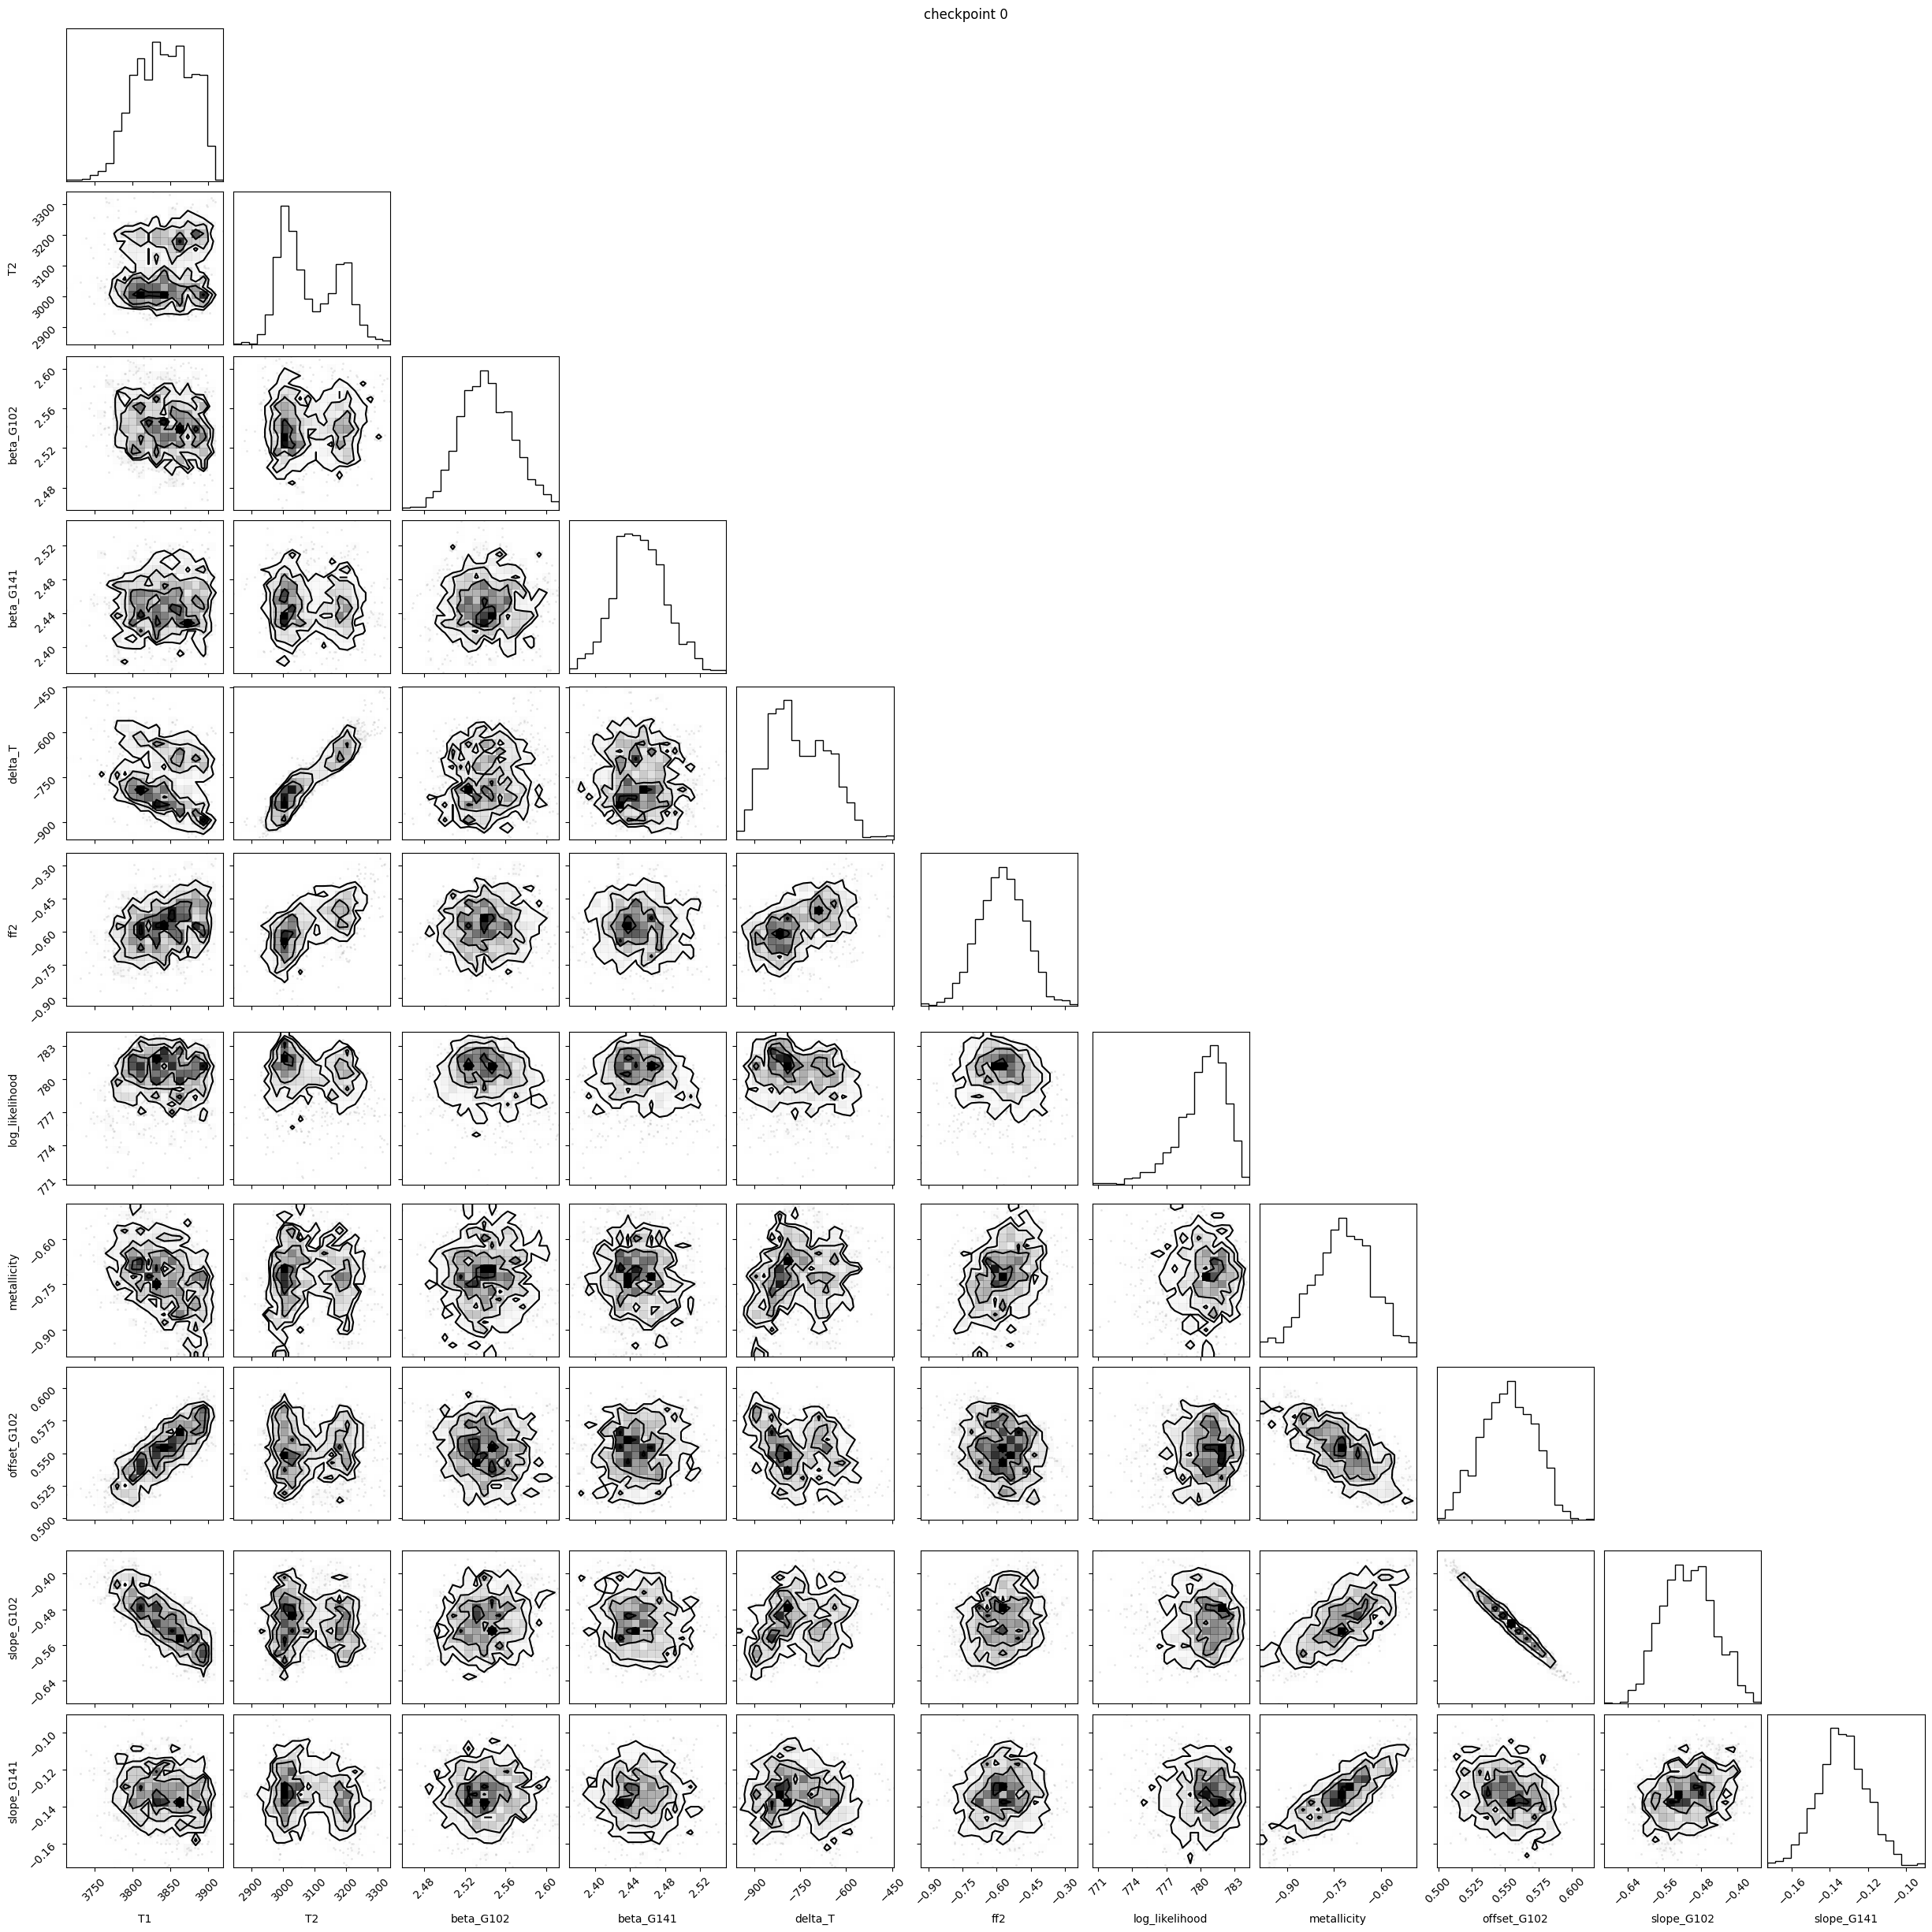

Median parameters from samples:
  T1: 3841.670387
  T2: 3059.695557
  beta_G102: 2.540411
  beta_G141: 2.449581
  delta_T: -767.422958
  ff2: -0.574306
  log_likelihood: 780.484625
  metallicity: -0.722886
  offset_G102: 0.552582
  slope_G102: -0.507554
  slope_G141: -0.133347
Maximum log likelihood: 784.277470
BIC: -1513.420653


  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

...

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

Corner for checkpoint 1


/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


<Figure size 640x480 with 0 Axes>

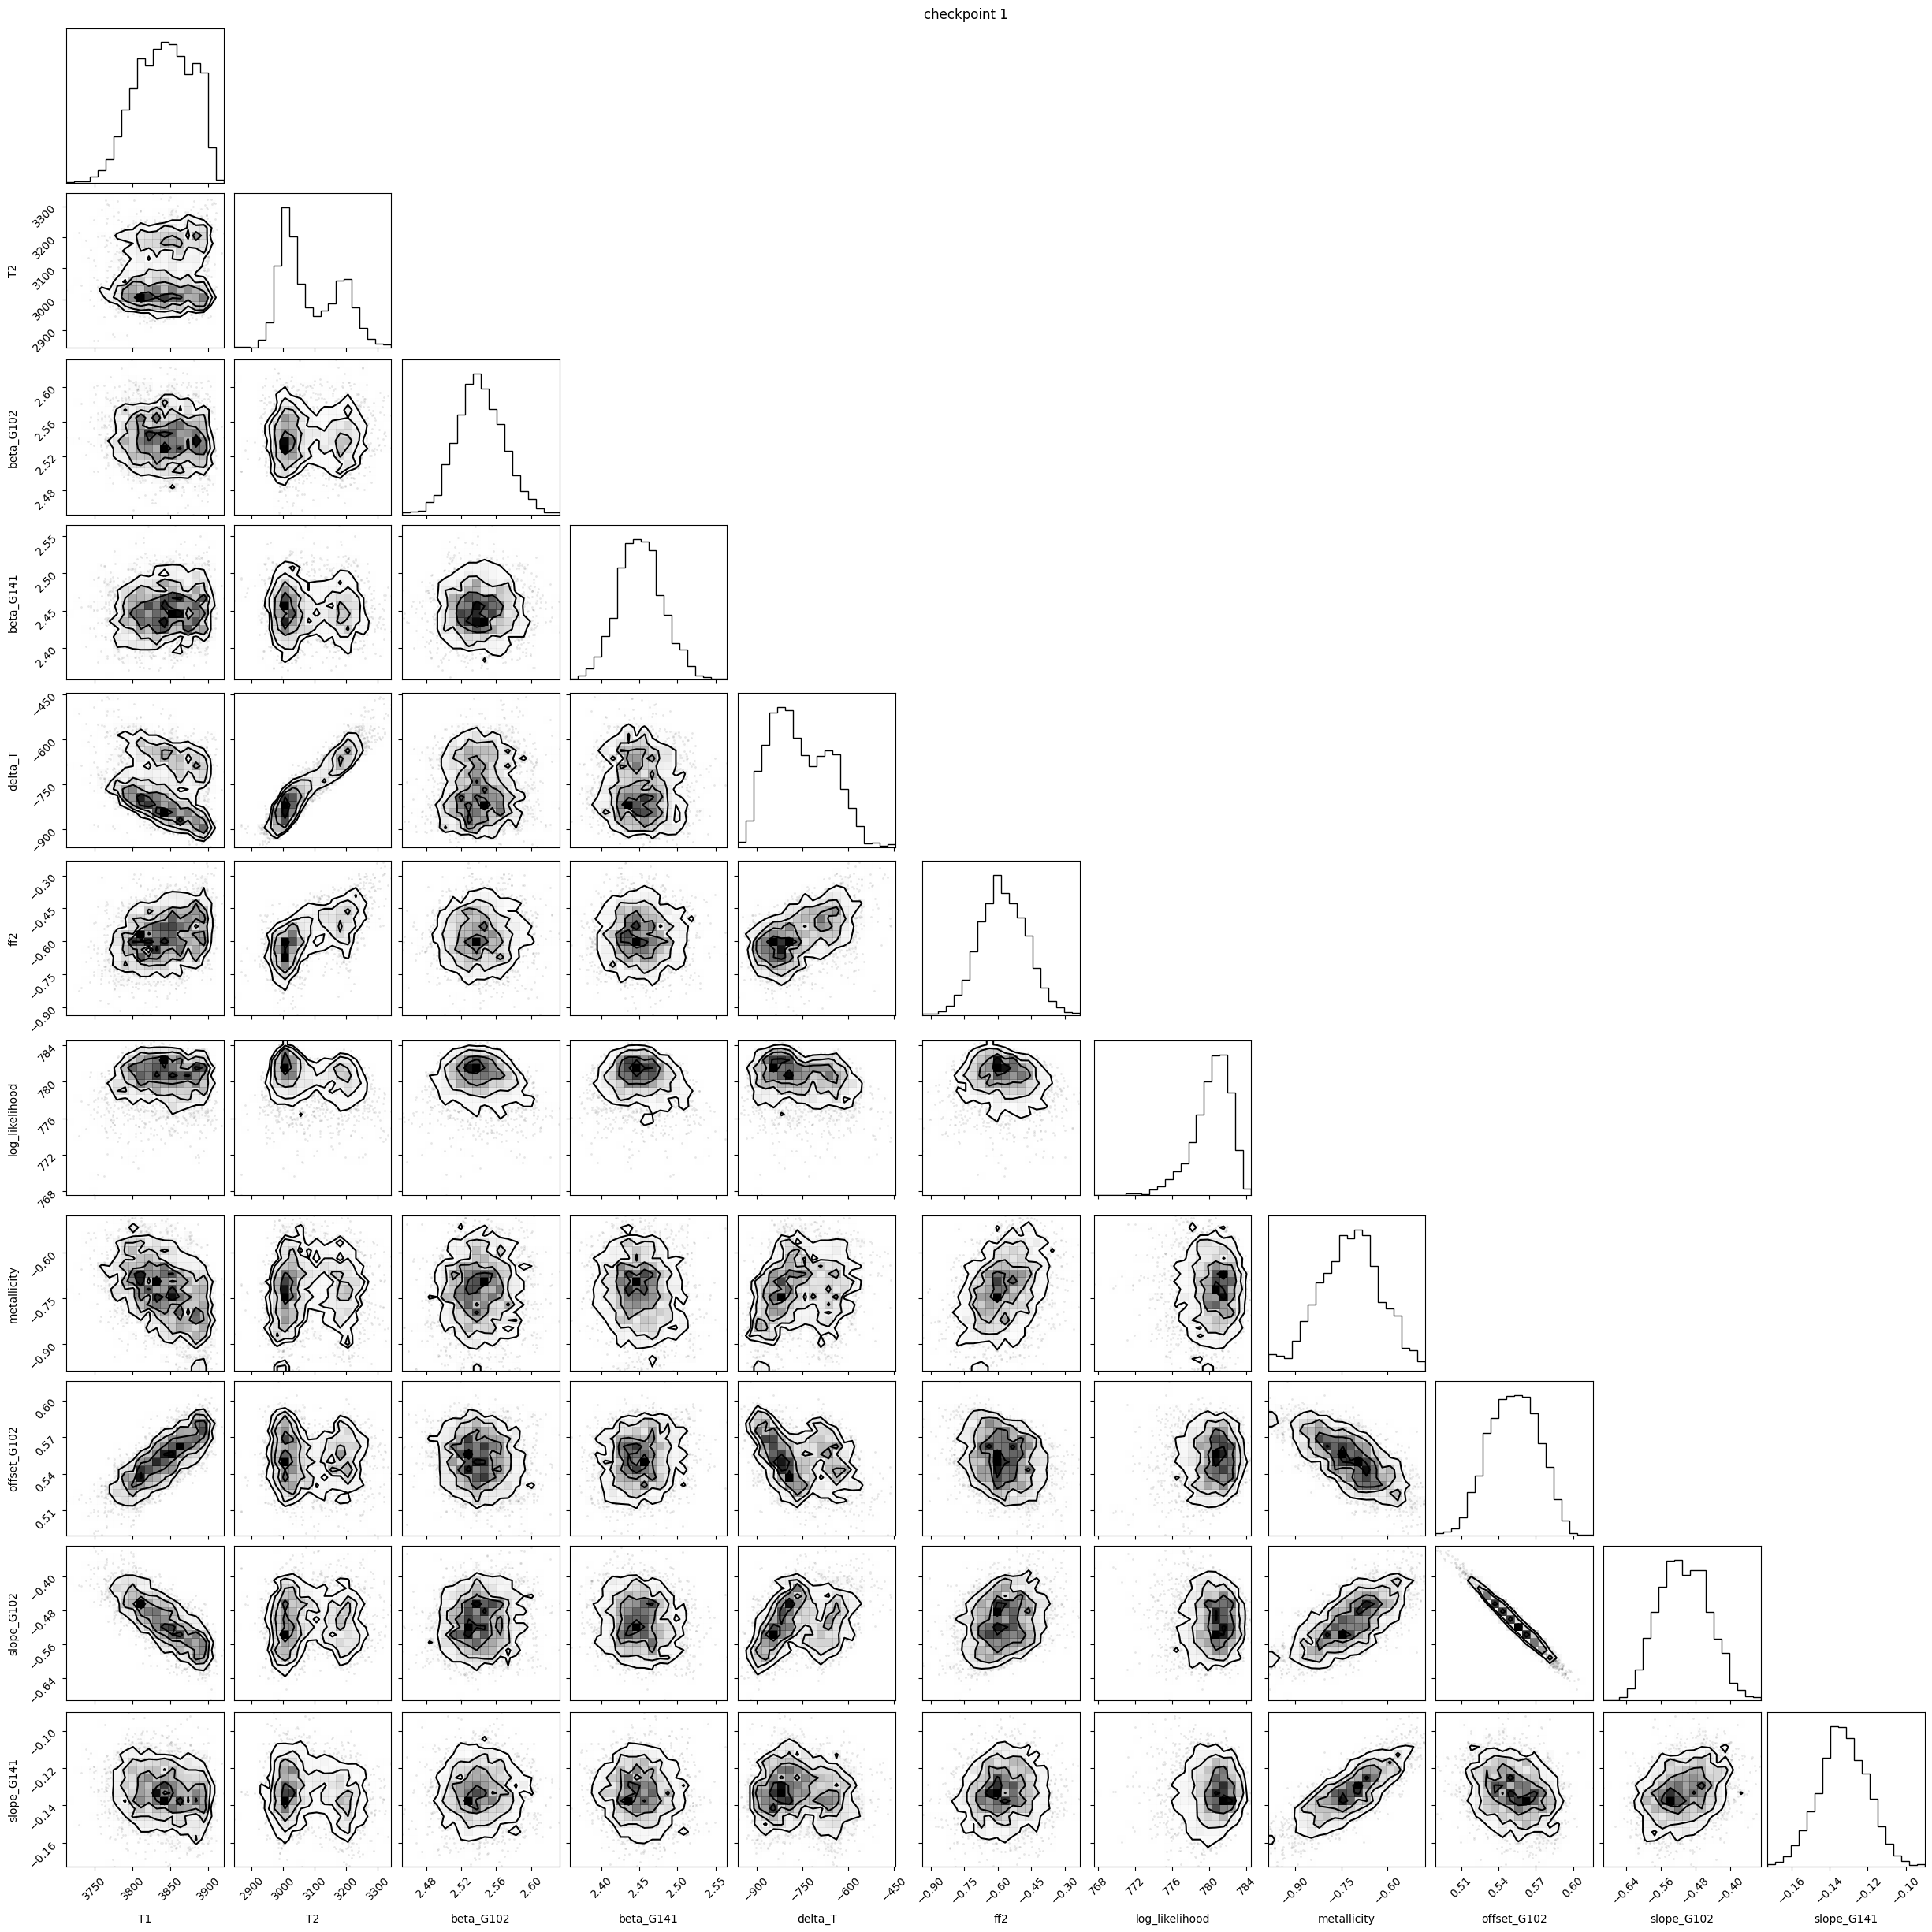

Median parameters from samples:
  T1: 3842.723162
  T2: 3052.427098
  beta_G102: 2.540614
  beta_G141: 2.450040
  delta_T: -770.997576
  ff2: -0.579641
  log_likelihood: 780.555516
  metallicity: -0.720644
  offset_G102: 0.552670
  slope_G102: -0.507921
  slope_G141: -0.133049
Maximum log likelihood: 784.515701
BIC: -1513.897115

                   mean       std    median      5.0%     95.0%     n_eff     r_hat
           T1   3841.20     36.06   3842.72   3790.92   3902.16    829.76      1.01
    beta_G102      2.54      0.03      2.54      2.50      2.59   1048.31      1.01
    beta_G141      2.45      0.03      2.45      2.40      2.50   1147.21      1.00
      delta_T   -756.84     95.55   -771.00   -909.17   -613.65    460.12      1.00
          ff2     -0.58      0.11     -0.58     -0.74     -0.40    863.56      1.00
  metallicity     -0.72      0.10     -0.72     -0.88     -0.56    610.76      1.01
  offset_G102      0.55      0.02      0.55      0.52      0.59    742.75      1

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
T1,3841.203,36.059,3780.538,3902.037,1.225,0.611,874.0,1087.0,1.01
T2,3084.366,93.009,2957.606,3249.230,4.567,1.403,512.0,1154.0,1.01
beta_G102,2.542,0.027,2.494,2.593,0.001,0.001,1093.0,1088.0,1.01
beta_G141,2.451,0.030,2.395,2.508,0.001,0.001,1156.0,1318.0,1.01
delta_T,-756.837,95.554,-914.425,-592.834,4.454,1.607,497.0,974.0,1.00
ff2,-0.576,0.105,-0.778,-0.389,0.004,0.002,900.0,1489.0,1.00
log_likelihood,780.194,2.141,776.147,783.588,0.072,0.069,947.0,1224.0,1.01
metallicity,-0.723,0.099,-0.911,-0.542,0.004,0.003,623.0,421.0,1.01
offset_G102,0.552,0.020,0.517,0.587,0.001,0.000,755.0,899.0,1.01
slope_G102,-0.507,0.056,-0.607,-0.403,0.002,0.001,761.0,1459.0,1.01


<Figure size 640x480 with 0 Axes>

In [ ]:
bt_lib = 'generic-fullgrid-fixedlogg' # GNS93, generic, CIFIST, AGSS2009
n_temps = 2
n_warmup = 5_00
n_samples = 2_000
n_chains = 8
n_check = 2

# Get the model function and callback
model_func, get_max_likelihood = numpyro_model(N_temps=n_temps, return_max_likelihood=True)

model_designation = f'jointvisit_{n_temps}T_{n_samples}_{n_chains}chains_SED_btsettl_{bt_lib}'

rng_key = PRNGKey(42)

sampler = NUTS(
    model_func,  # Use the returned function
    dense_mass=True
)

mcmc = MCMCWithCheckpoints(
    sampler, 
    num_warmup=n_warmup, 
    num_samples=n_samples,
    num_chains=n_chains
)

mcmc.run_checkpoints(rng_key, n_checkpoints=n_check, on_checkpoint=post_batch_viz_save)

mcmc.print_summary()

# Extract maximum likelihood after sampling
if get_max_likelihood is not None:
    samples = mcmc.get_samples()
    max_log_lik = get_max_likelihood(samples)
    print(f"Maximum log likelihood: {max_log_lik:.6f}")

result = arviz.from_numpyro(mcmc)

'Save the result'
result.to_netcdf(f'../../data/samples/{model_designation}')

'Print the summary'
arviz.summary(result)

In [9]:
'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo

/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 2400 posterior samples and 248 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   773.00    19.78
p_loo       12.93        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      247   99.6%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    1    0.4%


Maximum Likelihood Parameters:
  metallicity = -0.804


/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(



Temperature components: ['3873K', '3006K']

FILLING FACTORS FOR EACH COMPONENT (from full posterior)
Component 1 (T = 3873K):
  Median = 0.7916 (79.16%)
  Mean ± Std = 0.7876 ± 0.0404
  16th-84th percentile = [0.7468, 0.8269]
  Range = [0.6310, 0.8964]
Component 2 (T = 3006K):
  Median = 0.2084 (20.84%)
  Mean ± Std = 0.2124 ± 0.0404
  16th-84th percentile = [0.1731, 0.2532]
  Range = [0.1036, 0.3690]

Sum of median filling factors: 1.0000



/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_37626/2661768688.py:90: UserWarning: The figure layout has changed to tight
  plt.tight_layout()



Maximum Likelihood Filling Factors (for comparison):
  Component 1: 0.8058 (80.58%)
  Component 2: 0.1942 (19.42%)
Plotting 200 random posterior samples...


/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_37626/2661768688.py:174: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


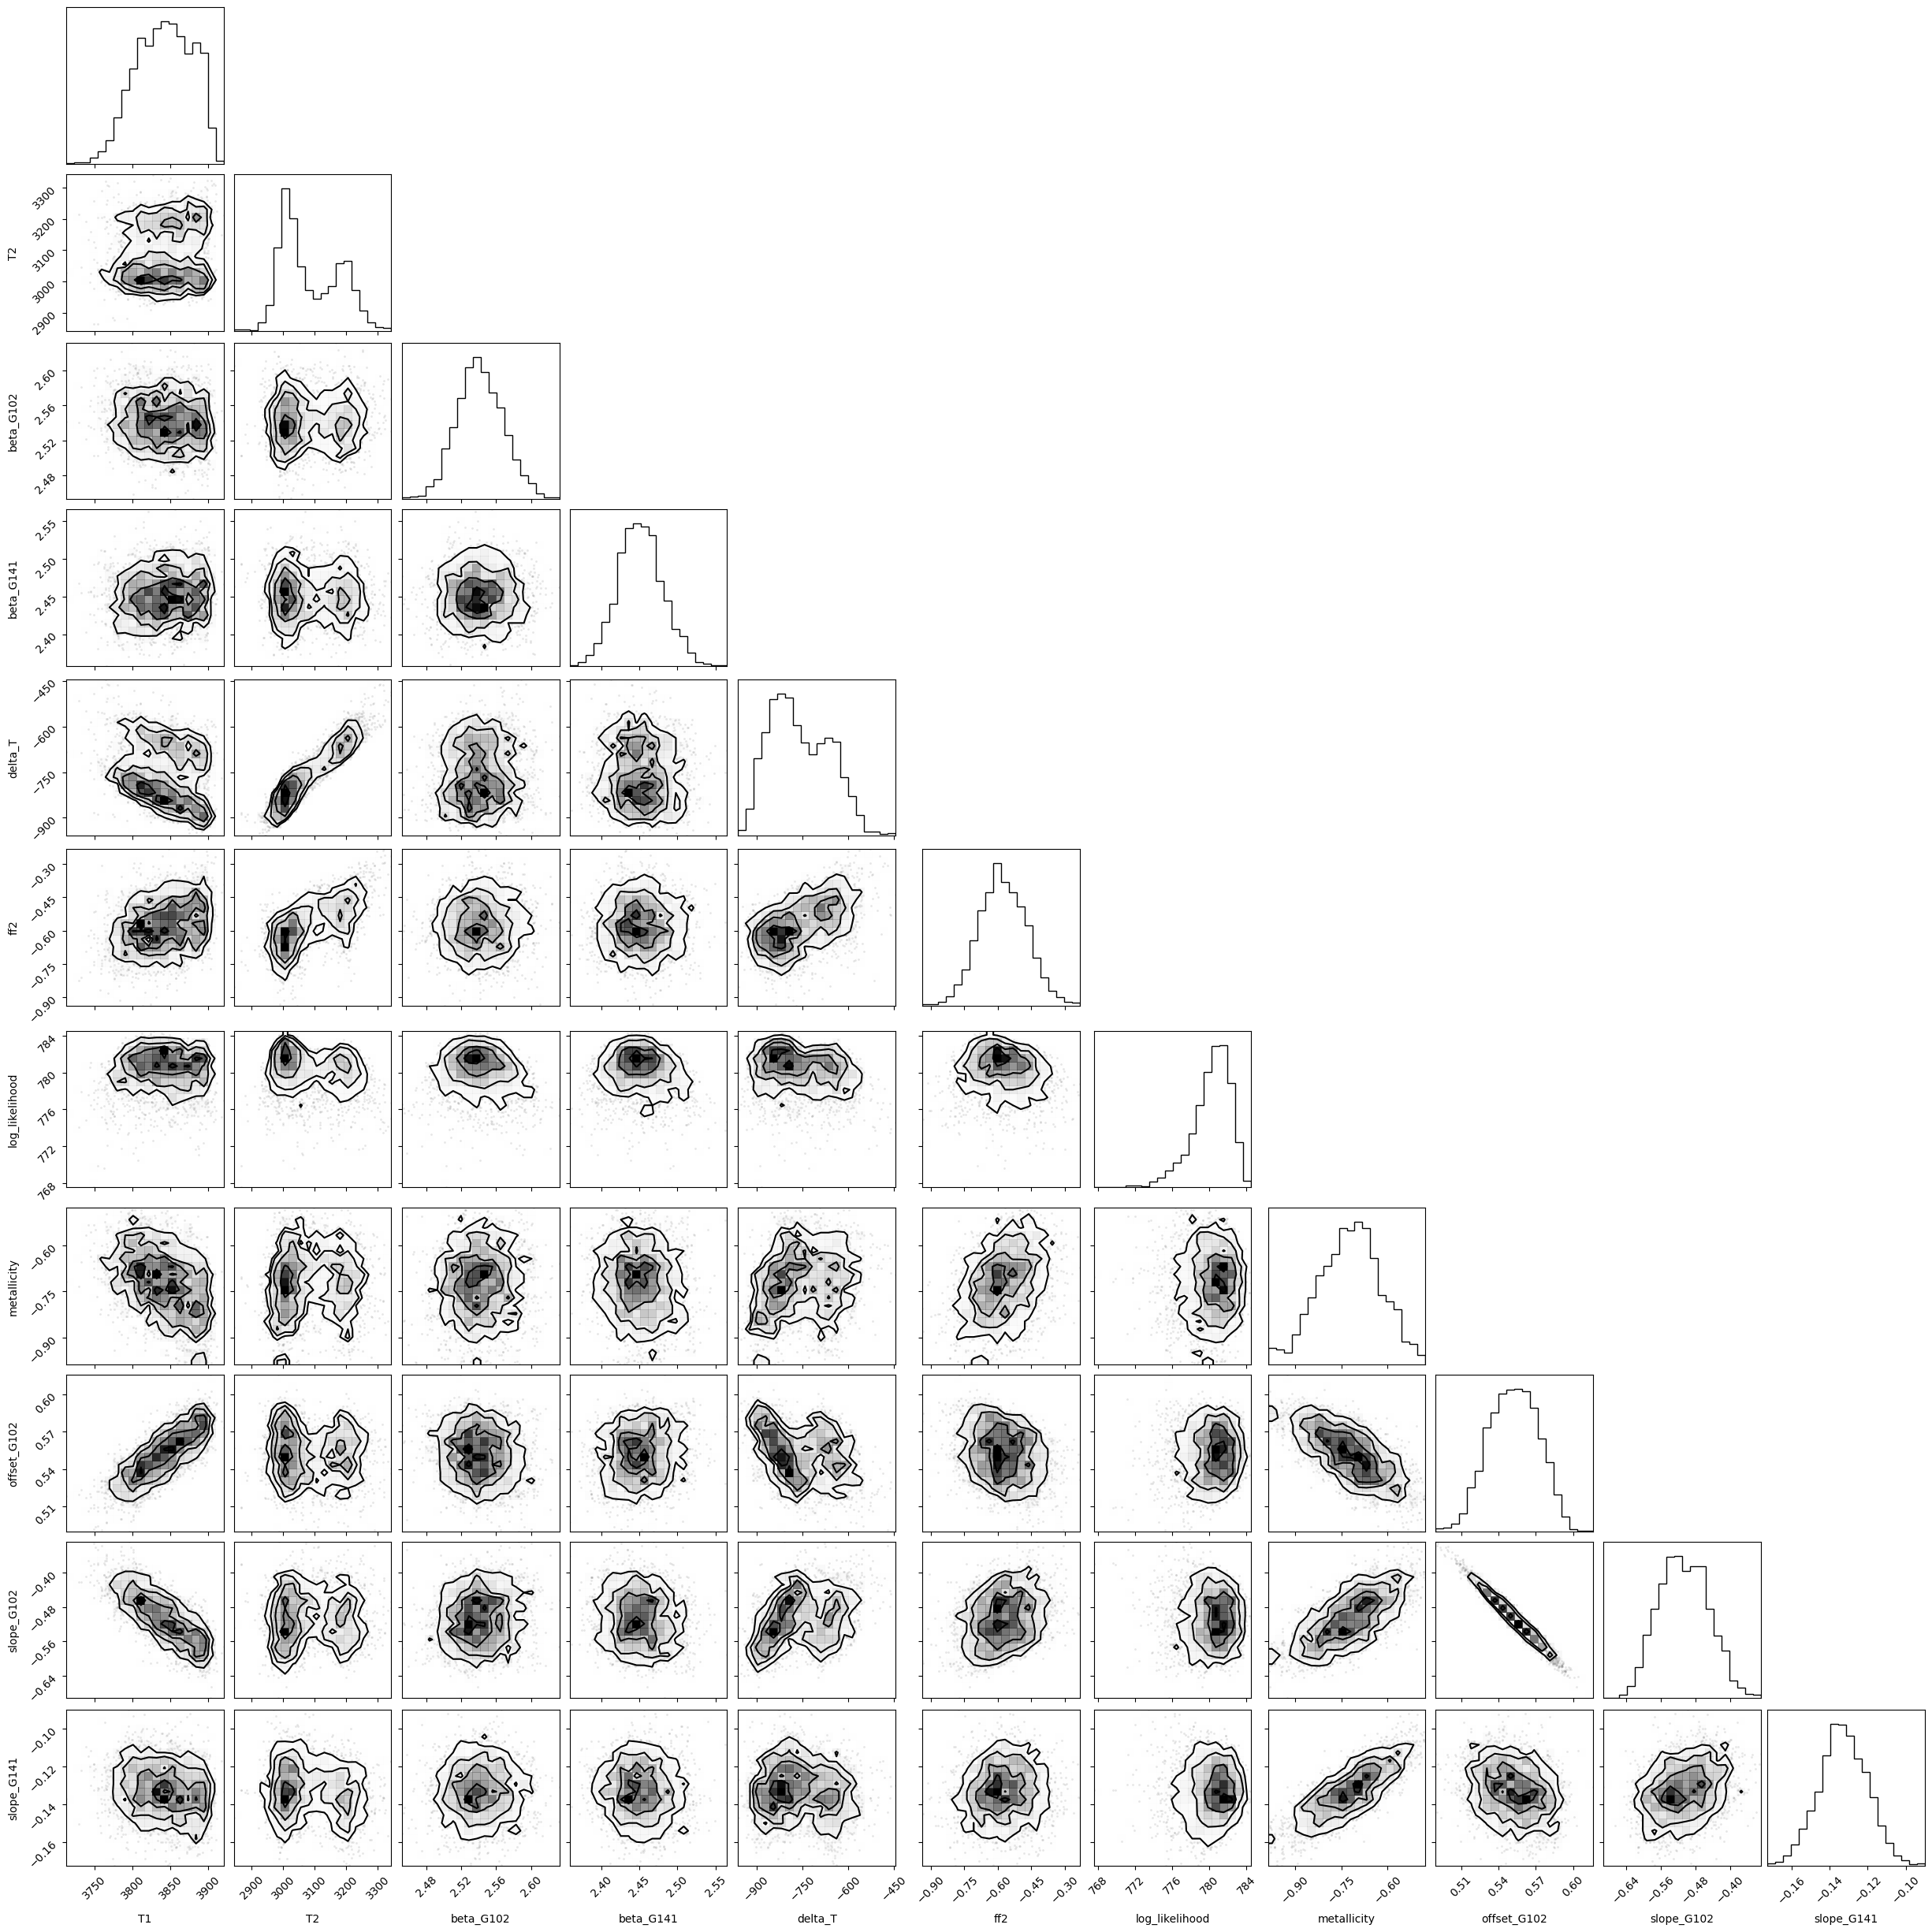

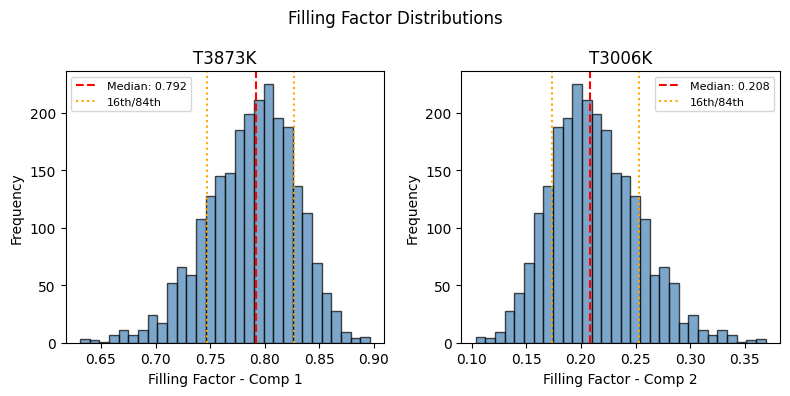

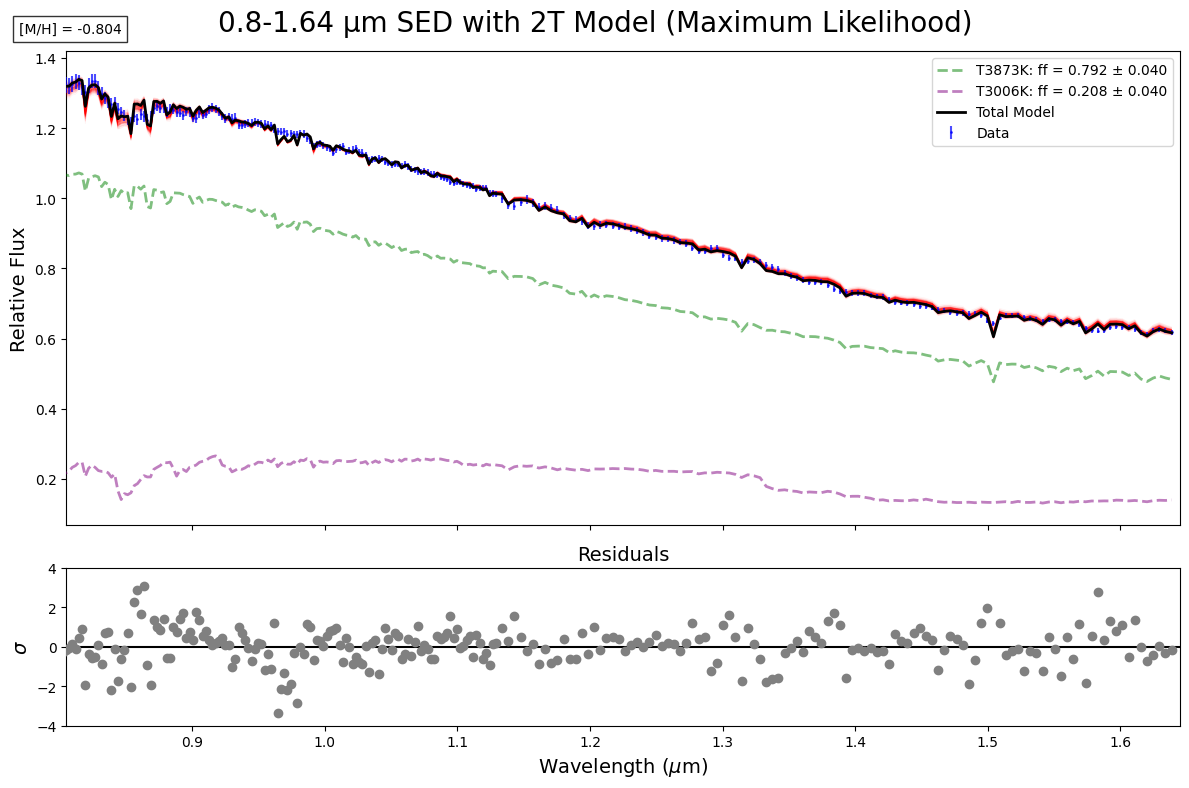

In [10]:
plot_sed_fit_results(mcmc, model_designation, n_temps)

## Run 3T Model

In [ ]:
bt_lib = 'generic-fullgrid-fixedlogg' # GNS93, generic, CIFIST, AGSS2009
n_temps = 3
n_warmup = 1_00
n_samples = 3_00
n_chains = 8
n_check = 2

# Get the model function and callback
model_func, get_max_likelihood = numpyro_model(N_temps=n_temps, return_max_likelihood=True)

model_designation = f'jointvisit_{n_temps}T_{n_samples}_{n_chains}chains_SED_btsettl_{bt_lib}'

rng_key = PRNGKey(42)

sampler = NUTS(
    model_func,  # Use the returned function
    dense_mass=True
)

mcmc = MCMCWithCheckpoints(
    sampler, 
    num_warmup=n_warmup, 
    num_samples=n_samples,
    num_chains=n_chains
)

mcmc.run_checkpoints(rng_key, n_checkpoints=n_check, on_checkpoint=post_batch_viz_save)

mcmc.print_summary()

# Extract maximum likelihood after sampling
if get_max_likelihood is not None:
    samples = mcmc.get_samples()
    max_log_lik = get_max_likelihood(samples)
    print(f"Maximum log likelihood: {max_log_lik:.6f}")

result = arviz.from_numpyro(mcmc)

'Save the result'
result.to_netcdf(f'../../data/samples/{model_designation}')

'Print the summary'
arviz.summary(result)

# Post-Inference Analysis

In [ ]:
'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo

In [ ]:
plot_sed_fit_results(mcmc, model_designation, n_temps)

# Compare multiple models of the same dataset

In [ ]:
compare_dict = {}

compare_dict['model_1'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_3T_2000_6chains_SED_btsettl_NextGenAGSS2009')
compare_dict['model_2'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_2T_2000_6chains_SED_btsettl_NextGenAGSS2009')
compare_dict['model_3'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_1T_2000_6chains_SED_btsettl_NextGenAGSS2009')
# compare_dict['model_4'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_2T_2000_6chains_SED_btsettl_Generic')
# compare_dict['model_3'] = arviz.InferenceData.from_netcdf('../../data/samples/')

arviz.compare(compare_dict)

From https://num.pyro.ai/en/latest/tutorials/bad_posterior_geometry.html

In general it is difficult to assess whether the samples returned from HMC or NUTS represent accurate (approximate) samples from the posterior. Two general rules of thumb, however, are to look at the effective sample size (ESS) and r_hat diagnostics returned by mcmc.print_summary(). If we see values of r_hat in the range (1.0, 1.05) and effective sample sizes that are comparable to the total number of samples num_samples (assuming thinning=1) then we have good reason to believe that HMC is doing a good job. If, however, we see low effective sample sizes or large r_hats for some of the variables (e.g. r_hat = 1.15) then HMC is likely struggling with the posterior geometry. In the following we will use r_hat as our primary diagnostic metric.